In [263]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [264]:
# Téléchargement des dataframes depuis la base de données des BAAC.
urls_y = {
    2022: {
        "carac" : "https://www.data.gouv.fr/api/1/datasets/r/5fc299c0-4598-4c29-b74c-6a67b0cc27e7",
        "lieux" : "https://www.data.gouv.fr/api/1/datasets/r/a6ef711a-1f03-44cb-921a-0ce8ec975995",
        "usagers" : "https://www.data.gouv.fr/api/1/datasets/r/62c20524-d442-46f5-bfd8-982c59763ec8"
    },
    2023 : {
        "carac" : "https://www.data.gouv.fr/api/1/datasets/r/104dbb32-704f-4e99-a71e-43563cb604f2",
        "lieux" : "https://www.data.gouv.fr/api/1/datasets/r/8bef19bf-a5e4-46b3-b5f9-a145da4686bc",
        "usagers" : "https://www.data.gouv.fr/api/1/datasets/r/68848e2a-28dd-4efc-9d5f-d512f7dbe66f"
    },
    2024 : {
        "carac" : "https://www.data.gouv.fr/api/1/datasets/r/83f0fb0e-e0ef-47fe-93dd-9aaee851674a",
        "lieux" : "https://www.data.gouv.fr/api/1/datasets/r/228b3cda-fdfb-4677-bd54-ab2107028d2d",
        "usagers" : "https://www.data.gouv.fr/api/1/datasets/r/f57b1f58-386d-4048-8f78-2ebe435df868"
    }
}

# Dictionnaire qui contiendra les dataframes pour chaque année en vue de la concaténation

dfs = {}

yrl = [2022,2023,2024]
names = ["carac","lieux","usagers"]

for name in names:
    list_df = []
    for yr in yrl:
        url = urls_y[yr][name]
        df_yr = pd.read_csv(url,sep=";") # Le séparateur utilisé est ";"
        df_yr.insert(1,"year",yr) # Colonne année pour distinguer les accidents entre années en vue des opérations de fusion de dataframes
        list_df.append(df_yr)

    concatenated_df_type = pd.concat(list_df,ignore_index=True) # On fait fi de l'index
    dfs[name] = concatenated_df_type # On associe le dataframe des trois années au type de dataframe

dfs

# Prend environ 40 secondes à tourner

C:\Users\berna\AppData\Local\Temp\ipykernel_9120\4247346482.py:31: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df_yr = pd.read_csv(url,sep=";") # Le séparateur utilisé est ";"
C:\Users\berna\AppData\Local\Temp\ipykernel_9120\4247346482.py:31: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df_yr = pd.read_csv(url,sep=";") # Le séparateur utilisé est ";"


{'carac':          Accident_Id  year  jour  mois    an   hrmn  lum dep    com  agg  int  \
 0       2.022000e+11  2022    19    10  2022  16:15    1  26  26198    2    3   
 1       2.022000e+11  2022    20    10  2022  08:34    1  25  25204    2    3   
 2       2.022000e+11  2022    20    10  2022  17:15    1  22  22360    2    6   
 3       2.022000e+11  2022    20    10  2022  18:00    1  16  16102    2    3   
 4       2.022000e+11  2022    19    10  2022  11:45    1  13  13103    1    1   
 ...              ...   ...   ...   ...   ...    ...  ...  ..    ...  ...  ...   
 164521           NaN  2024    10     7  2024  02:05    5  94  94065    2    3   
 164522           NaN  2024    30    11  2024  15:27    1  92  92062    2    1   
 164523           NaN  2024    24    10  2024  20:40    3  29  29068    1    1   
 164524           NaN  2024    30    11  2024  15:40    1  92  92012    2    1   
 164525           NaN  2024    10     7  2024  08:30    1  94  94028    2    1   
 
     

In [265]:
if "an" in dfs["carac"].columns:
    dfs["carac"].drop(columns=["an"],inplace=True) # Colonne an redondante avec colonne year

Observons la longueur de chacun des dataframes :

In [266]:
for n,content in dfs.items(): 
    print(n,len(content))

carac 164526
lieux 196410
usagers 377638


In [323]:
for name in names:
    dfs[name].to_csv(f"data_interm/new/{name}_new.csv",index=False)

### Charger .csv

In [326]:
names = ["carac","lieux","usagers"]

lieux_new = pd.read_csv("data_interm/new/lieux_new.csv")
usagers_new = pd.read_csv("data_interm/new/usagers_new.csv")
carac_new = pd.read_csv("data_interm//new/carac_new.csv")

Il est normal que le dataframe "usagers" soit le plus long : en effet, pour chaque accident corporel, on peut compter plusieurs victimes. Il est plus surprenant que "lieux" soit plus long que "carac". 
Observons les doublons :

In [327]:
lieux_new["Num_Acc"].value_counts().head(20)

Num_Acc
202300035508    5
202400050330    5
202300039940    4
202300053680    4
202300036543    4
202300007795    4
202300034748    4
202400005122    4
202300046485    4
202300006227    4
202300011843    4
202300054010    4
202300015235    4
202300016172    4
202400005927    4
202400012290    4
202400012979    4
202400013470    4
202400017817    4
202400017969    4
Name: count, dtype: int64

In [328]:
lieux_new[lieux_new["Num_Acc"]==202300035508]

,Num_Acc,year,catr,voie,v1,v2,circ,nbv,vosp,prof,pr,pr1,plan,lartpc,larrout,surf,infra,situ,vma
101231,202300035508,2023,4,BOULEVARD DE BEAUSEJOUR,0,NaN,1,0,0,1,0,0,1,NaN,-1,1,0,1,30
101232,202300035508,2023,4,BOULEVARD EMILE AUGIER,0,NaN,3,2,0,1,-1,-1,1,NaN,-1,1,9,1,50
101233,202300035508,2023,4,CHAUSSEE LA MUETTE,0,NaN,3,1,3,1,-1,-1,1,NaN,-1,1,6,1,50
101234,202300035508,2023,4,RUE D ANDIGNE,0,NaN,1,1,0,1,0,0,1,NaN,-1,1,0,1,30
101235,202300035508,2023,4,RUE LARGILLIERE,0,NaN,2,2,0,1,0,0,1,NaN,-1,1,0,1,30


In [329]:
sum(carac_new["Num_Acc"].value_counts()>1)

0

Pour le dataset "carac", nous avons deux colonnes "Num_Acc" et "Accident_Id" qui représentent la même chose ; la colonne a changé de nom avec les années. Vérifions qu'il n'y a pas de contradiction entre les deux colonnes, et qu'elles ne sont jamais toutes deux vides.

In [330]:
carac_new.head(20)

,Accident_Id,year,jour,mois,hrmn,lum,dep,com,agg,int,atm,col,adr,lat,long,Num_Acc
0,2.022000e+11,2022,19,10,16:15,1,26,26198,2,3,1,3,TEIL(vieille route du),"44,5594200000","4,7257200000",NaN
1,2.022000e+11,2022,20,10,08:34,1,25,25204,2,3,1,3,Miranda,"46,9258100000","6,3462000000",NaN
2,2.022000e+11,2022,20,10,17:15,1,22,22360,2,6,1,2,ROND POINT DE BREZILLET,"48,4931620000","-2,7604390000",NaN
3,2.022000e+11,2022,20,10,18:00,1,16,16102,2,3,8,6,LOHMEYER (RUE),"45,6926520000","-0,3262900000",NaN
4,2.022000e+11,2022,19,10,11:45,1,13,13103,1,1,1,2,ROUTE DE JEAN MOULIN-RN 538,"43,6755790366","5,0927031775",NaN
5,2.022000e+11,2022,6,10,14:00,1,13,13056,2,2,1,3,TURCAN FRANCIS,"43,4127500000","5,0505900000",NaN
6,2.022000e+11,2022,20,10,21:00,5,13,13063,2,1,1,1,CARNOT RUE,"43,5822900000","5,0034300000",NaN
7,2.022000e+11,2022,15,10,21:00,5,12,12145,2,2,1,3,JAURES JEAN (AVENUE),"44,1036000000","3,0798400000",NaN
8,2.022000e+11,2022,20,10,09:43,1,10,10387,2,1,8,6,LOMBARDS (AVENUE),"48,2717969874","4,0788030624",NaN
9,2.022000e+11,2022,19,10,12:30,1,10,10387,2,9,1,-1,PREMIER MAI (RUE DU),"48,3041200000","4,0883300000",NaN


En règle générale, ne jamais dsupprimer par défaut une colonne, toujours garder et descendre au fur et à mesure.

In [331]:
carac_new["dep"].nunique()
# Il y a 107 départements exactement

107

In [332]:
carac_new["year"].head(20)

0     2022
1     2022
2     2022
3     2022
4     2022
5     2022
6     2022
7     2022
8     2022
9     2022
10    2022
11    2022
12    2022
13    2022
14    2022
15    2022
16    2022
17    2022
18    2022
19    2022
Name: year, dtype: int64

In [333]:
carac_new.groupby(["com","year"])["Num_Acc"].nunique().mean()
# Il y'a en moyenne 4.86 accidents par an et par département

np.float64(3.226801382611008)

In [334]:
carac_new.groupby(["com","year"])["Num_Acc"].nunique().median()
# La médiane est beaucoup plus faible, ce qui indique qu'on a des 
# départements avec beaucoup plus d'accidents que d'autres. 
# Nous nous intéresserons à ceci plus loin.

np.float64(1.0)

In [335]:
c = carac_new.groupby("com")["Num_Acc"].count()
c.sample(20) 

# il semble que la feature ville peut être informative.


com
01321     0
76535     0
47125     0
66059     0
59122    31
49090     1
60297     1
83071    18
91017     4
67430     2
76094     0
95690     1
24296     1
81052     1
10363     3
62666     1
68012     4
59085     0
46336     1
51171     4
Name: Num_Acc, dtype: int64

In [336]:
if "Accident_Id" in carac_new.columns:
    carac_new["Num_Acc"] = carac_new["Num_Acc"].fillna(carac_new["Accident_Id"])   # On fusionne Accident_Id et Num_Acc, qui représentent le même indicateur
    carac_new.drop(columns=["Accident_Id"],inplace=True)

col_data = carac_new.pop("Num_Acc")
carac_new.insert(0,"Num_Acc",col_data) # On replace la colonne "Num_Acc" en index 0 des colonnes du dataframe

"Lieux" indique les différentes voies liées à l'accident lorsqu'il a eu lieu dans une intersection complexe. Il contient par ailleurs différentes informations sur le lieu de l'accident (type de route **catr**, l'état de la surface **surf**, la vitesse maximale autorisée **vma**).

Les données les plus générales sont les "caractéristiques de l'accident", uniques pour chaque accident. Dans chaque accident, on a des données sur le lieu de l'accident et l'avant-accident qui est différent selon les acteurs impliqués. Enfin, la partie "usagers" comporte des informations sur chacun des usagers impliqués dans l'accident ; c'est le dataset le plus large.

## Formatting Dataframe 2022-2024
### Caractéristiques
Observons le dataset "carac".

In [337]:
carac_new.head(20)
# We should likely delete the adr column. We will keep long and lat since we will merge with meteorogical data later on. We can 
# also delete the "com" (city) and "dep" (department) rows, which should be little informative (unless we take into account that some dpts' routes have 
# much more traffic. But wouldn't it already be captured by "autoroute" and "hour", mostly ?)

# What can be smart is to do target encoding with department. Be careful not to leak data.

,Num_Acc,year,jour,mois,hrmn,lum,dep,com,agg,int,atm,col,adr,lat,long
0,2.022000e+11,2022,19,10,16:15,1,26,26198,2,3,1,3,TEIL(vieille route du),"44,5594200000","4,7257200000"
1,2.022000e+11,2022,20,10,08:34,1,25,25204,2,3,1,3,Miranda,"46,9258100000","6,3462000000"
2,2.022000e+11,2022,20,10,17:15,1,22,22360,2,6,1,2,ROND POINT DE BREZILLET,"48,4931620000","-2,7604390000"
3,2.022000e+11,2022,20,10,18:00,1,16,16102,2,3,8,6,LOHMEYER (RUE),"45,6926520000","-0,3262900000"
4,2.022000e+11,2022,19,10,11:45,1,13,13103,1,1,1,2,ROUTE DE JEAN MOULIN-RN 538,"43,6755790366","5,0927031775"
5,2.022000e+11,2022,6,10,14:00,1,13,13056,2,2,1,3,TURCAN FRANCIS,"43,4127500000","5,0505900000"
6,2.022000e+11,2022,20,10,21:00,5,13,13063,2,1,1,1,CARNOT RUE,"43,5822900000","5,0034300000"
7,2.022000e+11,2022,15,10,21:00,5,12,12145,2,2,1,3,JAURES JEAN (AVENUE),"44,1036000000","3,0798400000"
8,2.022000e+11,2022,20,10,09:43,1,10,10387,2,1,8,6,LOMBARDS (AVENUE),"48,2717969874","4,0788030624"
9,2.022000e+11,2022,19,10,12:30,1,10,10387,2,9,1,-1,PREMIER MAI (RUE DU),"48,3041200000","4,0883300000"


On a une importante granularité pour le moment précis de l'accident. Observons s'il y'a des données manquantes.

In [338]:
carac_new[carac_new.isnull().any(axis=1)]

,Num_Acc,year,jour,mois,hrmn,lum,dep,com,agg,int,atm,col,adr,lat,long
81,2.022000e+11,2022,21,10,14:50,1,89,89039,1,1,1,1,NaN,"47,8170240000","3,8992600000"
121,2.022000e+11,2022,22,10,17:25,1,02,02163,1,1,1,2,NaN,"48,9721000000","3,2805820000"
181,2.022000e+11,2022,9,8,01:25,3,11,11069,1,1,1,6,NaN,"43,1911100000","2,3318100000"
215,2.022000e+11,2022,9,8,18:15,1,79,79196,1,1,1,7,NaN,"46,9447150000","-0,1325600000"
233,2.022000e+11,2022,10,8,09:35,1,19,19180,1,1,1,7,NaN,"45,5113510000","2,2201930000"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164438,2.024001e+11,2024,3,5,00:20,3,33,33262,2,1,1,6,NaN,"45,00655100","-0,63045300"
164443,2.024001e+11,2024,24,3,21:06,5,33,33119,2,9,1,6,NaN,"44,85613000","-0,53378000"
164468,2.024001e+11,2024,7,6,17:20,1,49,49129,1,1,1,2,NaN,"47,49609600","-0,52210800"
164480,2.024001e+11,2024,24,10,15:29,1,39,39126,1,1,1,5,NaN,"46,59107500","5,95572700"


L'adresse exacte est souvent indisponible. Par ailleurs, la donnée textuelle n'est pas toujours formatée de la même manière (elle est probablement rentrée manuellement sans règles particulières pour chaque accident). 

In [339]:
a = carac_new.groupby(["adr","lat","long"],as_index=False)["Num_Acc"].count()
a[a["Num_Acc"]>5]

,adr,lat,long,Num_Acc
12073,A1,"48,91936344","2,35754643",6
12942,A13,"48,83397544","2,16646875",7
12999,A13,"48,83887386","2,19360470",6
13668,A15,"48,94967230","2,28022080",6
13703,A15,"48,95858710","2,27405291",7
13748,A15,"48,96346787","2,26421667",8
14707,A4,"48,8172046066","2,4285178250",11
14732,A4,"48,81737044","2,42861395",6
14802,A4,"48,82050762","2,40183223",6
14817,A4,"48,82253799","2,39690691",7


On voit que l'adresse inclut également l'autoroute, et c'est là où il y'a le plus d'accidents corporels. Comme on dispose déjà d'informations sur la configuration de la route et qu'on dispose de toutes les longitudes et latitudes (cf. cellule ci-dessous), on peut supprimer la colonne "adresse", qui n'apporte rien de plus.

In [340]:
carac_new[["long","lat"]].isna().sum()

long    0
lat     0
dtype: int64

In [341]:
a

,adr,lat,long,Num_Acc
0,6609B Avenue de l'Hermitage,"43,82856100","1,73438900",1
1,A64,"43,2612140000","1,1165610000",1
2,Av. du Maréchal de Lattre de Tassigny,"48,85810000","2,49136000",1
3,(nouvelle rocade),"44,1756700000","0,6248200000",1
4,-,"43,23630000","2,37030000",1
...,...,...,...,...
157761,Étang de Vesvre,"46,59301700","3,93636200",1
157762,échangereur D55/D8II,"47,78691500","7,43315200",1
157763,écluse,"48,15031200","7,59091400",1
157764,écluse du quengo,"48,06300200","-2,74094900",1


### Usagers

La définition de "Blessé hospitalisé" a changé depuis 2018, ce qui rend la comparaison exacte impossible entre 2005-2018 et 2019-2024. Pour internaliser le bruit, nous fusionnons les valeurs "Blessé hospitalisé" et "Blessé léger" pour avoir une variable plus générale "Blessé".

In [342]:
dict1 = {
    -1:"NA",
    1:"Indemne",
    2:"Tué",
    3:"Blessé", # Blessé hospitalisé -> Blessé
    4:"Blessé", # Blessé léger -> Blessé
}

dict2 = {
    "NA":-1,
    "Indemne":0,
    "Blessé":1,
    "Tué":2,
    }
usagers_new["gravité"]=usagers_new["grav"].apply(lambda x:dict1[x])
usagers_new["grav"]=usagers_new["gravité"].apply(lambda x :dict2[x])

>Pour rappel, **grav** peut prendre quatre valeurs : 
>* -1 = NA
>* 1 = Indemne
>* 2 = Tué
>* 3 = Blessé hospitalisé
>* 4 = Blessé léger

<Axes: xlabel='grav', ylabel='Count'>

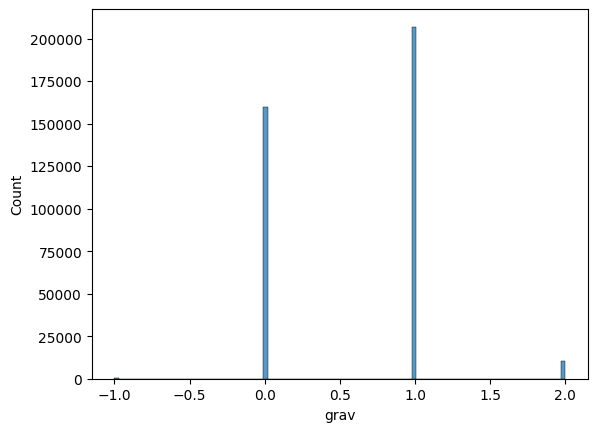

In [343]:
sns.histplot(usagers_new["grav"])

In [344]:
print(round(len(usagers_new[usagers_new["grav"]==-1])/len(usagers_new),5)*100,
len(usagers_new[usagers_new["grav"]==-1]))

# 0.01% des données sont -1 (pas de renseignement) pour la gravité

0.095 359


Seules 359 lignes sur plus de 350 000 ont des données manquantes sur la target variable "grav". Elles sont extrêmement minoritaires, nous pouvons donc les supprimer.

In [345]:
usagers_new=usagers_new[usagers_new!=-1]

In [346]:
round(len(usagers_new[usagers_new["grav"]==2])/len(usagers_new),5)*100

2.749

3% des accidents corporels recensés mènent à la mort. Il n'est donc pas suffisant d'utiliser l'accuracy comme métrique de précision de nos prédictions. Effectivement, un algorithme de prédiction naïf aurait raison 97% du temps.

### Lieux
Observons le dataset "lieux".

In [347]:
lieux_new[lieux_new["Num_Acc"].duplicated(keep=False)].sort_values(by="Num_Acc")
#Keep=False conserve les duplicates, contrairement au défaut keep=First qui ne montre que la première ligne.

,Num_Acc,year,catr,voie,v1,v2,circ,nbv,vosp,prof,pr,pr1,plan,lartpc,larrout,surf,infra,situ,vma
55302,202300000001,2023,4,RUE DE RIVOLI,0,NaN,1,2,0,1,-1,-1,1,NaN,-1,2,0,1,30
55303,202300000001,2023,4,RUE SAINT FLORENTIN,0,NaN,1,1,0,1,-1,-1,1,NaN,-1,2,0,1,30
55305,202300000003,2023,3,5,0,NaN,2,4,0,1,1,0,1,NaN,-1,2,5,1,50
55306,202300000003,2023,3,87,0,NaN,2,4,0,1,1,0,1,NaN,-1,2,5,1,50
55308,202300000005,2023,4,NaN,0,NaN,1,1,0,1,-1,-1,1,NaN,-1,2,0,1,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196393,202400054388,2024,4,NaN,-1,NaN,2,-1,0,1,-1,-1,1,NaN,-1,1,0,1,30
196398,202400054393,2024,3,120,0,NaN,2,4,2,1,0,0,1,NaN,-1,1,9,1,50
196399,202400054393,2024,3,NaN,0,NaN,1,1,1,1,0,0,1,NaN,-1,1,0,8,30
196404,202400054398,2024,3,165,0,NaN,2,3,0,1,0,0,1,NaN,9,2,5,4,50


Nous supprimons la colonne voie, qui est bruitée, et peu informative. On supprime donc également v1 et v2, qui donnent l'adresse. On supprime de même les colonnes concernant les points de repère (bornes kilométriques : pr1 et pr2). En effet, nous disposons déjà des longitudes et des latitudes pour chaque enregistrement (cf. caractéristiques plus haut).

A contrario, la VMA (vitesse maximale autorisée), la catégorie de route (catr - autoroute, route urbaine...), l'état de la surface (surf - conditions de la route : verglas, pluie, neige), le régime de circulation (circ - bidirectionnel, unidirectionnel,...), le type d'infrastructure (infra - ponts, tunnels ou carrefours), situation de l'accident (situ - où a précisément eu lieu l'accident : sur la chaussée, sur la bande d'arrêt d'urgence,...), sont particulièrement importantes pour notre prédiction.

Les colonnes plan, prof, nbv, lartpc, larrout, vosp, donnent des informations précises sur la configuration des lieux de l'accident. En particulier, prof (topographie), plan (courbure de la route), larrout (largeur de la route) sont très intéressantes.

In [348]:
lieux_new=lieux_new.drop(columns=["voie","v1","v2","pr","pr1"])
lieux_new

,Num_Acc,year,catr,circ,nbv,vosp,prof,plan,lartpc,larrout,surf,infra,situ,vma
0,202200000001,2022,4,2,2,0,1,1,NaN,-1,1,0,1,50
1,202200000002,2022,4,2,2,0,1,1,NaN,-1,1,0,1,50
2,202200000003,2022,3,-1,2,0,1,1,NaN,-1,1,5,1,50
3,202200000004,2022,4,1,1,0,2,1,NaN,4,1,0,1,30
4,202200000005,2022,3,2,2,0,1,1,NaN,-1,1,0,1,80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196405,202400054398,2024,3,1,1,-1,1,1,NaN,-1,2,5,4,-1
196406,202400054399,2024,3,1,1,2,1,2,NaN,-1,1,0,1,30
196407,202400054400,2024,2,1,2,0,2,1,NaN,10,1,0,1,110
196408,202400054401,2024,3,2,3,0,1,1,NaN,"10,5",1,0,1,50


In [349]:
lieux_new[lieux_new["Num_Acc"]==202300000001]

,Num_Acc,year,catr,circ,nbv,vosp,prof,plan,lartpc,larrout,surf,infra,situ,vma
55302,202300000001,2023,4,1,2,0,1,1,NaN,-1,2,0,1,30
55303,202300000001,2023,4,1,1,0,1,1,NaN,-1,2,0,1,30


In [350]:
lieux_new["Num_Acc"].isin(usagers_new["Num_Acc"]).all()
# On a bien une correspondance parfaite entre les lignes de "carac" et les lignes de "usagers". 

np.True_

In [351]:
carac_new["Num_Acc"].isin(lieux_new["Num_Acc"]).all()
# On a également une correspondance entre les lignes de "carac" et les lignes de "lieux". On peut donc bien fusionner en faisant correspondre 
# toutes les lignes avec chaque dataset

np.True_

### Premier merge

Nous souhaitons fusionner les données de 2022, 2023, et 2024, pour les dataframes usagers, carac, et lieux. 
Un problème est que nous avons plusieurs lignes par accident pour "lieux" et pour "usagers" : une ligne par victime dans "usagers", plusieurs lignes possibles dans "lieux" si l'accident s'est produit à une intersection. 

Comme nous observons ci-dessous, le dataframe "carac" dispose bien d'une seule ligne par accident.

In [352]:
(carac_new["Num_Acc"].value_counts()!=1).sum()

np.int64(0)

Si nous conservons toutes les lignes de "lieux", nous devrons dupliquer les lignes des victimes, ce qui faussera nos statistiques de sécurité routière (nombre de victimes gonflé). 

Nous devons donc aplatir les lignes du dataset "lieux".

In [353]:
for count in range(1,3):
    print(
    f"{round((lieux_new["Num_Acc"].value_counts()>count).sum()/len(lieux_new),3)*100}% des accidents \
ont strictement plus de {count} ligne(s) pour 'lieux'.")

16.0% des accidents ont strictement plus de 1 ligne(s) pour 'lieux'.
0.2% des accidents ont strictement plus de 2 ligne(s) pour 'lieux'.


In [354]:
print(lieux_new.duplicated().sum())

4445


Dans 16% des cas, nous avons deux routes pour l'accident (on est face à une intersection). Pour conserver l'information, nous créons une nouvelle variable "nb_routes" et nous sélectionnons la route principale (Autoroute>Nationale>Départementale>...) pour caractériser le lieu de l'accident. Comme les cas où on a plus de trois routes impliquées correspond à 0.2% des cas, nous pouvons supprimer ces enregistrements.

Nous faisons l'hypothèse que la gravité de l'accident sera principalement dictée par la route où la limite de vitesse est la plus élevée, où le le nombre de voies est le plus élevé, et où la largeur précise de chaque voie est la plus élevée.

On supprime d'abord les doublons parfaits.

In [355]:
lieux_new=lieux_new.drop_duplicates()
lieux_new

,Num_Acc,year,catr,circ,nbv,vosp,prof,plan,lartpc,larrout,surf,infra,situ,vma
0,202200000001,2022,4,2,2,0,1,1,NaN,-1,1,0,1,50
1,202200000002,2022,4,2,2,0,1,1,NaN,-1,1,0,1,50
2,202200000003,2022,3,-1,2,0,1,1,NaN,-1,1,5,1,50
3,202200000004,2022,4,1,1,0,2,1,NaN,4,1,0,1,30
4,202200000005,2022,3,2,2,0,1,1,NaN,-1,1,0,1,80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196405,202400054398,2024,3,1,1,-1,1,1,NaN,-1,2,5,4,-1
196406,202400054399,2024,3,1,1,2,1,2,NaN,-1,1,0,1,30
196407,202400054400,2024,2,1,2,0,2,1,NaN,10,1,0,1,110
196408,202400054401,2024,3,2,3,0,1,1,NaN,"10,5",1,0,1,50


In [356]:
lieux_new[lieux_new.duplicated(subset=["Num_Acc"],keep=False)]
#La feature qui change peut être complètement différente d'un accident à l'autre. 
#Nous devons donc hiérarchiser.

,Num_Acc,year,catr,circ,nbv,vosp,prof,plan,lartpc,larrout,surf,infra,situ,vma
55302,202300000001,2023,4,1,2,0,1,1,NaN,-1,2,0,1,30
55303,202300000001,2023,4,1,1,0,1,1,NaN,-1,2,0,1,30
55308,202300000005,2023,4,1,1,0,1,1,NaN,-1,2,0,1,30
55309,202300000005,2023,4,2,2,0,1,1,NaN,-1,2,0,1,30
55312,202300000008,2023,3,3,4,0,1,1,NaN,-1,2,0,1,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196393,202400054388,2024,4,2,-1,0,1,1,NaN,-1,1,0,1,30
196398,202400054393,2024,3,2,4,2,1,1,NaN,-1,1,9,1,50
196399,202400054393,2024,3,1,1,1,1,1,NaN,-1,1,0,8,30
196404,202400054398,2024,3,2,3,0,1,1,NaN,9,2,5,4,50


In [357]:
# Creation d'une feature binaire comptant le nombre de paramètres de lieux dans l'accident (1 ou 2)

lieux_new["nb_param_lieux"]=lieux_new.groupby(["year","Num_Acc"])["Num_Acc"].transform("size")
lieux_new

C:\Users\berna\AppData\Local\Temp\ipykernel_9120\1462081502.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lieux_new["nb_param_lieux"]=lieux_new.groupby(["year","Num_Acc"])["Num_Acc"].transform("size")


,Num_Acc,year,catr,circ,nbv,vosp,prof,plan,lartpc,larrout,surf,infra,situ,vma,nb_param_lieux
0,202200000001,2022,4,2,2,0,1,1,NaN,-1,1,0,1,50,1
1,202200000002,2022,4,2,2,0,1,1,NaN,-1,1,0,1,50,1
2,202200000003,2022,3,-1,2,0,1,1,NaN,-1,1,5,1,50,1
3,202200000004,2022,4,1,1,0,2,1,NaN,4,1,0,1,30,1
4,202200000005,2022,3,2,2,0,1,1,NaN,-1,1,0,1,80,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196405,202400054398,2024,3,1,1,-1,1,1,NaN,-1,2,5,4,-1,2
196406,202400054399,2024,3,1,1,2,1,2,NaN,-1,1,0,1,30,1
196407,202400054400,2024,2,1,2,0,2,1,NaN,10,1,0,1,110,1
196408,202400054401,2024,3,2,3,0,1,1,NaN,"10,5",1,0,1,50,1


In [358]:
lieux_new = lieux_new.sort_values(
    by=[
        "year", "Num_Acc", 
        "catr",      # Critère 1 : La classe administrative (1=Autoroute gagne)
        "vma",       # Critère 2 (Si catr égal) : La vitesse (80 gagne vs 50)
        "nbv",       # Critère 3 (Si catr et vma égaux) : Le gabarit (2 voies gagne)
        "larrout"    # Critère 4 (Si tout le reste égal) : La largeur précise de la voie (nous gardons la + grande)
    ],
    ascending=[
        True, True, 
        True,        # catr : croissant (1 est mieux)
        False,       # vma : décroissant (plus grand est mieux)
        False,       # nbv : décroissant
        False        # larrout : décroissant
    ]
)
lieux_clean = lieux_new.drop_duplicates(subset=["year", "Num_Acc"], keep="first")

In [359]:
lieux_clean

,Num_Acc,year,catr,circ,nbv,vosp,prof,plan,lartpc,larrout,surf,infra,situ,vma,nb_param_lieux
0,202200000001,2022,4,2,2,0,1,1,NaN,-1,1,0,1,50,1
1,202200000002,2022,4,2,2,0,1,1,NaN,-1,1,0,1,50,1
2,202200000003,2022,3,-1,2,0,1,1,NaN,-1,1,5,1,50,1
3,202200000004,2022,4,1,1,0,2,1,NaN,4,1,0,1,30,1
4,202200000005,2022,3,2,2,0,1,1,NaN,-1,1,0,1,80,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196404,202400054398,2024,3,2,3,0,1,1,NaN,9,2,5,4,50,2
196406,202400054399,2024,3,1,1,2,1,2,NaN,-1,1,0,1,30,1
196407,202400054400,2024,2,1,2,0,2,1,NaN,10,1,0,1,110,1
196408,202400054401,2024,3,2,3,0,1,1,NaN,"10,5",1,0,1,50,1


Maintenant que nous avons "aplati" le dataset "lieux", créons un premier dataset général qui fusionne les données de 2022,2023, et 2024 pour les dataframes **usagers**, **carac**, et **lieux** :

In [360]:
KEY = ["year","Num_Acc"]

df_final2224 = usagers_new\
    .merge(lieux_clean,on=KEY,how="left")\
    .merge(carac_new,on=KEY,how="left")

# On garde toutes les lignes usagers


print(df_final2224.shape[0]==usagers_new.shape[0])

# df_final et usagers_new font bien la même longueur.

True


In [361]:
df_final2224[~df_final2224["nbv"].str.isnumeric().fillna(False)]["nbv"]

430        -1
431        -1
469        -1
1217       -1
1218       -1
         ... 
376868     -1
376869     -1
377318     -1
377319     -1
377355     -1
Name: nbv, Length: 3763, dtype: object

In [362]:
df_final2224["nbv"]=pd.to_numeric(df_final2224["nbv"],errors="coerce")
df_final2224["lartpc"]=pd.to_numeric(df_final2224["lartpc"],errors="coerce")

# We turn into "nan" the nbv (nombre de voies) and lartpc (largeur du terre plein central)
# records that are not numbers

In [363]:
df_final2224.to_parquet("data_interm/df_final2224.parquet",index=False)

### Parquet loading

In [364]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [365]:
df_final2224 = pd.read_parquet("data_interm/df_final2224.parquet")

In [366]:
df_final2224

,Num_Acc,year,id_usager,id_vehicule,num_veh,place,catu,grav,sexe,an_nais,...,lum,dep,com,agg,int,atm,col,adr,lat,long
0,202200000001,2022,1 099 700,813 952,A01,1.0,1,1.0,1.0,2008.0,...,1,26,26198,2,3,1,3,TEIL(vieille route du),"44,5594200000","4,7257200000"
1,202200000001,2022,1 099 701,813 953,B01,1.0,1,0.0,1.0,1948.0,...,1,26,26198,2,3,1,3,TEIL(vieille route du),"44,5594200000","4,7257200000"
2,202200000002,2022,1 099 698,813 950,B01,1.0,1,1.0,1.0,1988.0,...,1,25,25204,2,3,1,3,Miranda,"46,9258100000","6,3462000000"
3,202200000002,2022,1 099 699,813 951,A01,1.0,1,0.0,1.0,1970.0,...,1,25,25204,2,3,1,3,Miranda,"46,9258100000","6,3462000000"
4,202200000003,2022,1 099 696,813 948,A01,1.0,1,0.0,1.0,2002.0,...,1,22,22360,2,6,1,2,ROND POINT DE BREZILLET,"48,4931620000","-2,7604390000"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377633,202400054401,2024,203 859 570,155 686 119,Y01,1.0,1,1.0,2.0,1978.0,...,1,92,92012,2,1,1,3,JEAN JAURES (BOULEVARD) 63/215 - 70/208,"48,83286197","2,24394009"
377634,202400054401,2024,203 859 572,155 686 120,A01,1.0,1,0.0,1.0,1984.0,...,1,92,92012,2,1,1,3,JEAN JAURES (BOULEVARD) 63/215 - 70/208,"48,83286197","2,24394009"
377635,202400054402,2024,203 859 569,155 686 118,A01,1.0,1,1.0,1.0,1981.0,...,1,94,94028,2,1,1,4,Avenue de la Pompadour,"48,78330000","2,46660000"
377636,202400054402,2024,203 859 571,155 686 121,B01,1.0,1,1.0,2.0,1986.0,...,1,94,94028,2,1,1,4,Avenue de la Pompadour,"48,78330000","2,46660000"


On crée un score de gravité des accidents. Les blessés ont un poids de 1, les indemnes de 0, les morts de 5.

In [367]:
max_grav=df_final2224.groupby(["Num_Acc"])["grav"].transform("max") # Crée une colonne affichant le max de gravité de chaque accident
df_final2224["grav_weight"]=df_final2224["grav"].map({2:5,1:1,0:0})
s_grav_score=df_final2224.groupby("Num_Acc")["grav_weight"].transform("sum").rename("grav_score")

In [381]:
s_grav_score.head(20)

0     1.0
1     1.0
2     1.0
3     1.0
4     1.0
5     1.0
6     1.0
7     1.0
8     1.0
9     1.0
10    1.0
11    1.0
12    2.0
13    2.0
14    2.0
15    1.0
16    1.0
17    1.0
18    1.0
19    1.0
Name: grav_score, dtype: float64

### Carte accidents 22-24
Nous pouvons observer la carte des accidents de la route de ce dataframe.

In [382]:
df_map = df_final2224.drop_duplicates(subset=["Num_Acc"])[["lat","long"]].copy()

# Pour utiliser folium, on doit remplacer les virgules par des points dans long et lat

df_map["lat"]=pd.to_numeric(df_map["lat"].apply(lambda x:str(x).replace(',','.')))
df_map["long"]=pd.to_numeric(df_map["long"].apply(lambda x:str(x).replace(',','.')))

df_map.sample(20)

,lat,long
180464,50.653190,3.069080
336605,49.832225,2.828379
94755,48.955833,2.504014
34579,48.869597,2.237857
211346,49.358020,3.352850
63555,48.832590,2.531660
243294,43.313130,3.390698
332774,43.359065,3.435577
129946,45.790275,3.083451
308764,49.107820,1.499700


Pour la visualisation, on ne garde que la France Métropolitaine.

In [383]:
df_map = df_map[
    (41<df_map["lat"])&(df_map["lat"]<52) &
    (-6<df_map["long"])&(df_map["long"]<10)
]
df_map.head(20)

,lat,long
0,44.559420,4.725720
2,46.925810,6.346200
4,48.493162,-2.760439
6,45.692652,-0.326290
8,43.675579,5.092703
10,43.412750,5.050590
12,43.582290,5.003430
15,44.103600,3.079840
17,48.271797,4.078803
19,48.304120,4.088330


In [372]:
df_map[df_map["lat"]>90] 

,lat,long


Les données sont bien en GPS, pas besoin de les convertir (toutes les données sont inférieures à 90)

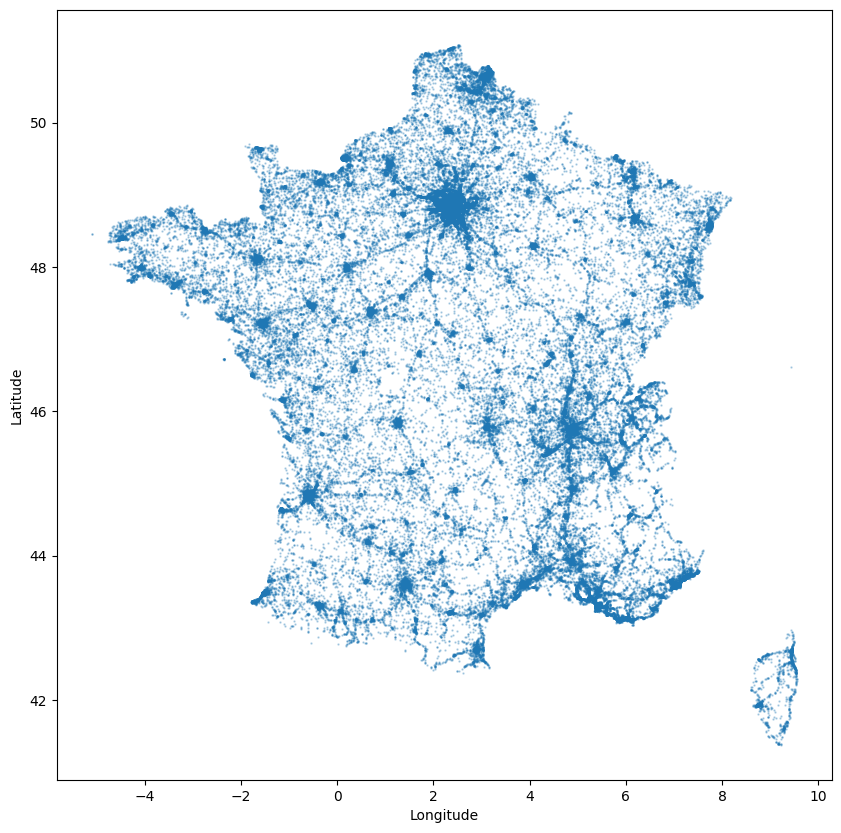

In [373]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
plt.scatter(df_map["long"],df_map["lat"],s=0.5,alpha=0.3)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

On peut clairement distinguer les zones urbaines des zones rurales. Il semble y'avoir une corrélation entre les zones à forte densité de population et le nombre d'accidents. Nous pouvons vérifier ça.

Note :  Si Folium renvoie "Make this notebook trusted to load map...", et si dans VSCode, faire Ctrl+Shift+P (Ouvre la barre de recherche avec >) puis écrire : Jupyter:Trust Notebook, puis appuyer sur Entrée. Ensuite, Restart Kernel et lancer le code. Si cela ne fonctionne pas, écrire Jupyter:Trust Notebook et relancer VSCode.

In [374]:
import geopandas as gpd
import folium 
from folium.plugins import HeatMap

gdf = gpd.GeoDataFrame(
    df_map,
    geometry = gpd.points_from_xy(df_map.long,df_map.lat),
)
print(f"Nous affichons exactement {len(gdf)} points.")

# Carte centrée sur la France
m = folium.Map(location=[46.6,2.2],zoom_start=6,tiles="CartoDB positron") # zoom_start dézoome la carte initiale

# Nous utilisons une carte de chaleur pour mieux voir les zones dangereuses
heat_data = gdf[["lat","long"]].values.tolist()
HeatMap(heat_data,radius=10,blur=10).add_to(m)


m


Nous affichons exactement 155076 points.


Comparons les données sur les accidents aux densités de population.

In [375]:
import pandas as pd
import matplotlib.pyplot as plt

print("Chargement des données...")
url_pop = "https://public.opendatasoft.com/api/explore/v2.1/catalog/datasets/correspondance-code-insee-code-postal/exports/csv?lang=fr&timezone=Europe%2FParis&use_labels=true&delimiter=%3B"

df_communes = pd.read_csv(url_pop, sep=';')

# Parsing coordonnées
if 'geo_point_2d' in df_communes.columns:
    df_communes[['lat_commune', 'lon_commune']] = df_communes['geo_point_2d'].str.split(',', expand=True).astype(float)

# Parsing population
if 'Population' not in df_communes.columns and 'population' in df_communes.columns:
    df_communes['Population'] = df_communes['population']

# Nettoyage
df_communes = df_communes.dropna(subset=['lat_commune', 'lon_commune', 'Population'])
df_communes = df_communes[
    (df_communes['lat_commune'] > 41) & (df_communes['lat_commune'] < 52) &
    (df_communes['lon_commune'] > -5) & (df_communes['lon_commune'] < 10)
]

df_accidents = df_map.copy()
df_accidents['lat'] = pd.to_numeric(df_accidents['lat'].astype(str).str.replace(',', '.'), errors='coerce')
df_accidents['long'] = pd.to_numeric(df_accidents['long'].astype(str).str.replace(',', '.'), errors='coerce')

df_accidents = df_accidents.dropna(subset=['lat', 'long'])


# plt.figure(figsize=(10, 10))

# # Couche 1 : Population

# plt.scatter(
#     df_communes['lon_commune'],
#     df_communes['lat_commune'],
#     s=df_communes['Population'],
#     c='blue',
#     alpha=0.3,       # Transparence modérée
#     linewidth=0,     # Pas de bordure pour garder l'aspect "point"
#     label='Population'
# )

# # Couche 2 : Accidents

# plt.scatter(
#     df_accidents['long'],
#     df_accidents['lat'],
#     s=0.5,           # Taille fixe très fine
#     c='red', 
#     alpha=0.3,       # Transparence pour voir la densité
#     linewidth=0,
#     label='Accidents'
# )

# plt.title("Carte brute : Population (Bleu) vs Accidents (Rouge)")
# plt.xlabel("Longitude")
# plt.ylabel("Latitude")
# plt.axis('equal')

# # Légende forcée (pour voir les points même s'ils sont petits sur la carte)
# lgnd = plt.legend()
# for handle in lgnd.legend_handles:
#     handle.set_alpha(1) 

# plt.show()

Chargement des données...


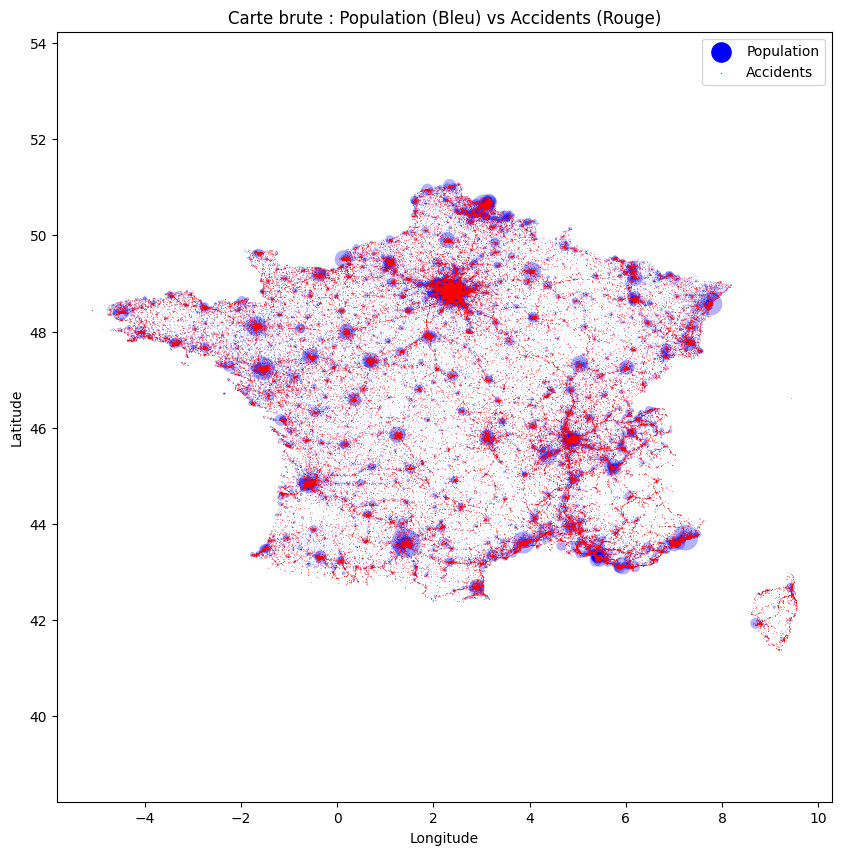

In [376]:
from modules import plot_maps_acc as pgf
pgf.plot_pop_nbacc(df_communes,df_accidents)


La corrélation entre la densité de population d'une région et la quantité d'accidents qui y a lieu est très nette. On peut s'y attendre : plus il y'a de personnes, plus il y'a de trafic, et plus il y'a d'accidents. Par contre, nous utiliserons plus tard la densité de population pour observer si justement, elle est négativement corrélée à la gravité d'un accident dans la région ou pas.

Modifions les couleurs pour pouvoir visualiser où ont lieux les accidents les plus graves (la gravité d'un accident correspond à l'état le plus grave existant parmi les victimes)

In [377]:
# On merge sur l'index 
df_accidents_grv=pd.merge(df_accidents,s_grav_score,left_index=True,right_index=True)
df_accidents_grv=df_accidents_grv.sort_values(by="grav_score",ascending=True)
df_accidents_grv.head(20)

,lat,long,grav_score
8,43.675579,5.092703,1.0
6,45.692652,-0.326290,1.0
4,48.493162,-2.760439,1.0
2,46.925810,6.346200,1.0
377628,48.886943,2.248636,1.0
104,48.863006,2.466063,1.0
102,48.864349,2.503312,1.0
100,48.858700,2.506540,1.0
98,48.904784,2.393401,1.0
96,48.884940,2.481560,1.0


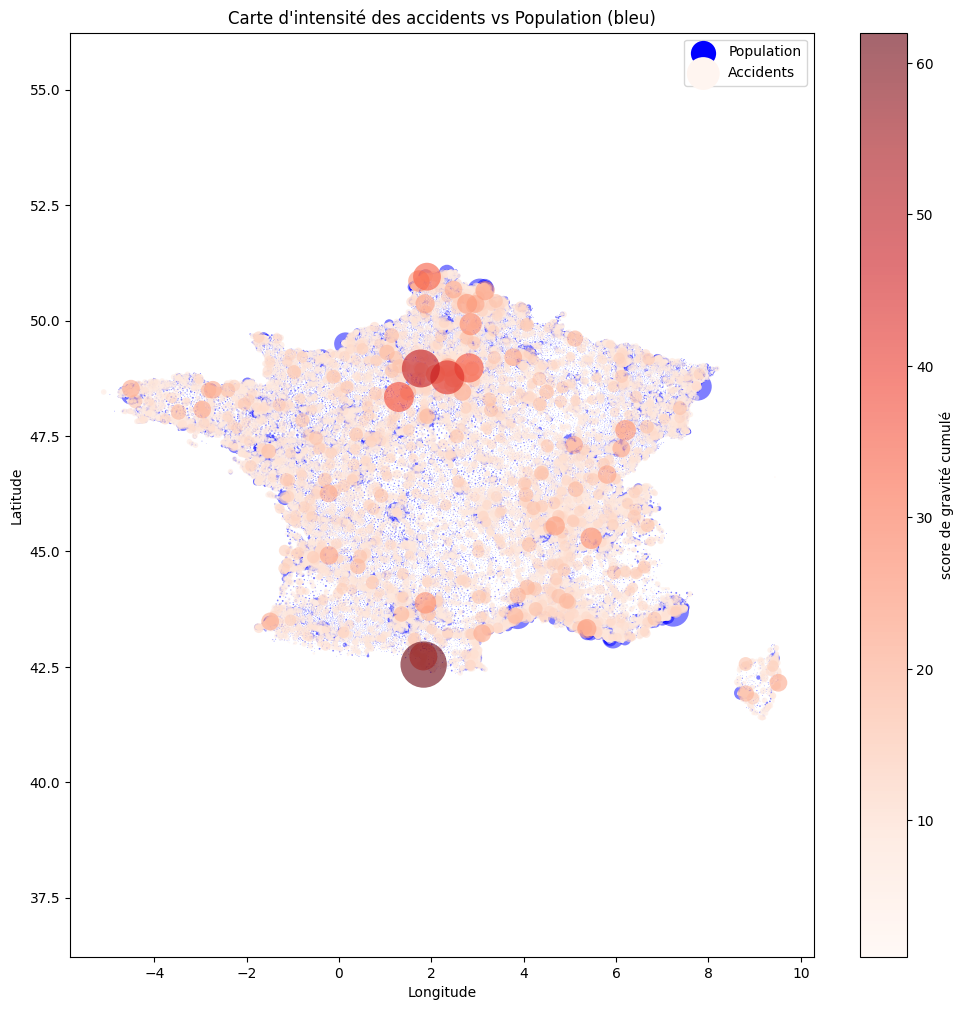

In [378]:
from modules import plot_maps_acc as pgf
pgf.plot_grav_score(df_communes,df_accidents_grv)

# plt.figure(figsize=(12, 12))

# plt.scatter(
#     df_communes['lon_commune'],
#     df_communes['lat_commune'],
#     s=df_communes['Population']*1.5,
#     c='blue',
#     alpha=0.5,       # Transparence modérée
#     linewidth=0,     # Pas de bordure pour garder l'aspect "point"
#     label='Population'
# )

# # Couche 2 : Accidents, colorés selon leur score de gravité 

# sc = plt.scatter(
#     df_accidents_grv['long'],
#     df_accidents_grv['lat'],
#     s=0.5+df_accidents_grv['grav_score']**1.7,           # Taille fixe très fine, qui grossit avec la gravité de l'accident
#     c=df_accidents_grv["grav_score"],
#     cmap="Reds", 
#     alpha=0.6,       # Transparence pour voir la densité
#     linewidth=0,
#     label='Accidents',
#     )

# plt.title("Carte d'intensité des accidents vs Population (bleu)")
# plt.xlabel("Longitude")
# plt.ylabel("Latitude")
# plt.axis('equal')

# cbar = plt.colorbar(sc) # Barre de couleur pour lire les scores
# cbar.set_label("score de gravité cumulé")

# # Légende forcée (pour voir les points même s'ils sont petits sur la carte)
# lgnd = plt.legend()
# for handle in lgnd.legend_handles:
#     handle.set_alpha(1) 

# plt.show()

## Dataframe 2005-2021

On supprime la colonne redondante d'index "Unnamed: 0" (liée au format d'importation) et on renomme les colonnes "num_acc" et "annee" pour être en cohérence avec le dataset df_final2224 :

In [379]:
url_05_21 = {
    "carac" : "https://www.data.gouv.fr/api/1/datasets/r/a3cac8bc-4a07-4124-8a08-633a3a91d40b",
    "lieux" : "https://www.data.gouv.fr/api/1/datasets/r/b7f25e45-de32-4801-b0eb-62989f1a7406",
    "usagers" : "https://www.data.gouv.fr/api/1/datasets/r/a64b1b9f-4d56-4b26-ae90-9f40b878e109"
}

In [380]:
df_old={}
for type,link in url_05_21.items():
    df_old[type] = pd.read_csv(link,
                               encoding="latin-1",  # Old files, with a different encoding than the recent ones
                               sep=",")
df_old

# Prend environ 3 min à tourner

KeyboardInterrupt: 

In [ ]:
print(df_old["carac"].columns,"\n",carac_new.columns)

Index(['Unnamed: 0', 'num_acc', 'mois', 'jour', 'hrmn', 'lum', 'agg', 'int',
       'atm', 'col', 'com', 'adr', 'gps', 'lat', 'long', 'dep', 'annee'],
      dtype='object') 
 Index(['Num_Acc', 'Unnamed: 0', 'year', 'jour', 'mois', 'hrmn', 'lum', 'dep',
       'com', 'agg', 'int', 'atm', 'col', 'adr', 'lat', 'long'],
      dtype='object')


In [ ]:
print(df_old["usagers"].columns,"\n",usagers_new.columns)

Index(['Unnamed: 0', 'num_acc', 'place', 'catu', 'grav', 'sexe', 'trajet',
       'secu', 'locp', 'actp', 'etatp', 'an_nais', 'num_veh', 'annee',
       'id_vehicule', 'secu1', 'secu2', 'secu3'],
      dtype='object') 
 Index(['Unnamed: 0', 'Num_Acc', 'year', 'id_usager', 'id_vehicule', 'num_veh',
       'place', 'catu', 'grav', 'sexe', 'an_nais', 'trajet', 'secu1', 'secu2',
       'secu3', 'locp', 'actp', 'etatp', 'gravité'],
      dtype='object')


In [ ]:
for type in ["usagers","carac","lieux"]:
    df_old[type]=df_old[type].rename(columns={"annee":"year","num_acc":"Num_Acc"})
    if "Unnamed: 0" in df_old[type].columns:
        df_old[type].drop(columns="Unnamed: 0",inplace=True)

Comme pour les données récentes, on supprime plusieurs colonnes de "lieux" :

In [ ]:
df_old["lieux"]=df_old["lieux"].drop(columns=["voie","v1","v2","pr","pr1"])
df_old["lieux"].head(20)

,Num_Acc,catr,circ,nbv,vosp,prof,plan,lartpc,larrout,surf,infra,situ,env1,year,vma
0,200500000001,3.0,2.0,2.0,0.0,1.0,1.0,0.0,63.0,1.0,0.0,1.0,0.0,2005,NaN
1,200500000002,2.0,0.0,2.0,1.0,1.0,1.0,0.0,100.0,1.0,0.0,5.0,0.0,2005,NaN
2,200500000003,2.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,2.0,0.0,5.0,0.0,2005,NaN
3,200500000004,3.0,2.0,2.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,2005,NaN
4,200500000005,3.0,2.0,2.0,0.0,1.0,3.0,0.0,59.0,2.0,0.0,3.0,0.0,2005,NaN
5,200500000006,3.0,2.0,2.0,0.0,1.0,3.0,0.0,70.0,2.0,0.0,5.0,0.0,2005,NaN
6,200500000007,3.0,2.0,0.0,0.0,1.0,1.0,0.0,78.0,1.0,0.0,1.0,0.0,2005,NaN
7,200500000008,3.0,2.0,2.0,0.0,1.0,3.0,0.0,69.0,1.0,0.0,3.0,0.0,2005,NaN
8,200500000009,3.0,2.0,2.0,0.0,0.0,1.0,0.0,67.0,1.0,0.0,1.0,0.0,2005,NaN
9,200500000010,2.0,0.0,2.0,0.0,1.0,1.0,0.0,70.0,2.0,0.0,1.0,0.0,2005,NaN


Ici aussi, nous avons bien un seul enregistrement des caractéristiques pour chaque identifiant d'accident. Mais c'est aussi le cas pour les enregistrements de lieux. Par contre, nous avons moins d'enregistrements pour "lieux" que pour "carac", ce qui signifie qu'il manque des données sur le lieu de certains accidents.

In [ ]:
print((df_old["carac"]["Num_Acc"].value_counts()!=1).sum())
print((df_old["lieux"]["Num_Acc"].value_counts()!=1).sum())

0
0


On voit que pour tous les accidents dans df_old["lieux"] nous avons un enregistrement dans df_old["carac"] :

In [ ]:
(~df_old["lieux"]["Num_Acc"].isin(df_old["carac"]["Num_Acc"])).sum()

np.int64(0)

Observons s'il existe des années pour lesquelles on n'a pas d'enregistrement "lieux".

In [ ]:
print(set(df_old["carac"]["year"].unique())-set(df_old["lieux"]["year"].unique()))

{np.int64(2020), np.int64(2021)}


Pour chaque année, combien a-t-on d'accidents dans "carac" sans enregistrement dans "lieux" ?

In [ ]:
for y in df_old["carac"]["year"].unique():
    s=0
    s+=(~df_old["carac"][df_old["carac"]["year"]==y]["Num_Acc"].isin(df_old["lieux"]["Num_Acc"])).sum()
    print(s,y)

0 2005
0 2006
0 2007
0 2008
0 2009
0 2010
0 2011
0 2012
0 2013
0 2014
0 2015
0 2016
0 2017
0 2018
0 2019
47744 2020
56518 2021


2020 et 2021 sont les seules années pour lesquelles on n'a pas d'enregistrement de "lieux".

In [ ]:
for name in names:
    df_old[name].to_csv(f"data_interm/old/{name}_old.csv")

### Charger csv

In [ ]:
carac_old = pd.read_csv("data_interm/old/carac_old.csv")
usagers_old = pd.read_csv("data_interm/old/usagers_old.csv")
lieux_old = pd.read_csv("data_interm/old/lieux_old.csv")

C:\Users\berna\AppData\Local\Temp\ipykernel_9120\3289329442.py:1: DtypeWarning: Columns (4,10,13,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  carac_old = pd.read_csv("data_interm/old/carac_old.csv")
C:\Users\berna\AppData\Local\Temp\ipykernel_9120\3289329442.py:2: DtypeWarning: Columns (9,14) have mixed types. Specify dtype option on import or set low_memory=False.
  usagers_old = pd.read_csv("data_interm/old/usagers_old.csv")


In [ ]:
KEY = ["Num_Acc","year"]
df_final_old = usagers_old.merge(carac_old,on=KEY,how="left").merge(lieux_old,on=KEY,how="left")

On télécharge en parquet pour faciliter l'exploration de données. On remarque que ACTP, qui correspond à l'action du piéton selon la typologie suivante : 
>Se déplaçant 
>* 0 - non renseigné ou sans objet 
>* 1 - Sens véhicule heurtant 
>* 2 - Sens inverse du véhicule 

>Divers  
>* 3 - Traversant 
>* 4 - Masqué 
>* 5 - Jouant – courant 
>* 6 - Avec animal 
>* 9 - Autre

contient des valeurs qui ne sont PAS numériques.

En effet, à partir de 2019, on a également -1 : non renseigné, A : Monte/Descend du véhicule, et B : inconnue.

In [ ]:
df_final_old["actp"]=df_final_old["actp"].astype(str)

In [ ]:
df_final_old["com"]=df_final_old["com"].astype(str)

In [ ]:
df_final_old["hrmn"]=df_final_old["hrmn"].astype(str)
df_final_old["hrmn"]=df_final_old["hrmn"].str.zfill(4)
df_final_old["hrmn"]=df_final_old["hrmn"].str[:2]+":"+df_final_old["hrmn"].str[2:]

#Horaire exact de l'accident. On normalise le format à heures (2 chiffres) : minutes (2 chiffres)

In [ ]:
# df_final_old.to_parquet("df_final_old.parquet")

In [ ]:
print(carac_old[["long","lat"]].isna().sum(),len(carac_old))
# Nous avons beaucoup de données manquantes sur la longitude et la latitude pour 2005-2021.

long    487072
lat     487068
dtype: int64 1121571


In [ ]:
(~lieux_old["vma"].isnull()).sum()

np.int64(58840)

Notons que la colonne vma a été ajoutée après 2019. C'est une feature très importante pour la gravité.

<Axes: xlabel='grav', ylabel='Count'>

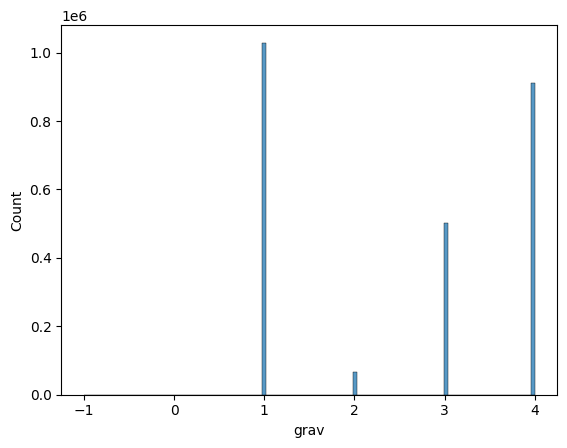

In [ ]:
sns.histplot(usagers_old["grav"])

<Axes: xlabel='grav', ylabel='Count'>

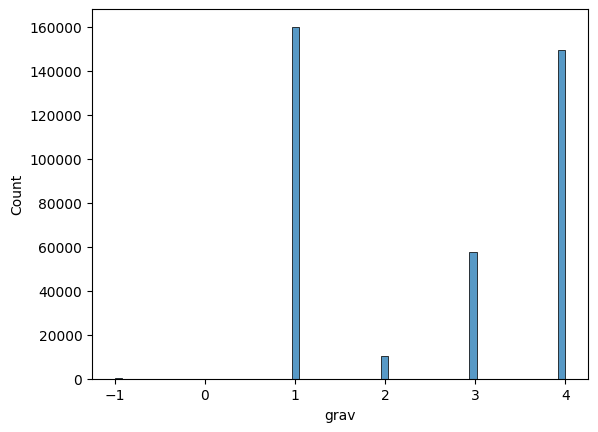

In [ ]:
sns.histplot(usagers_new["grav"])

<Axes: xlabel='grav', ylabel='Count'>

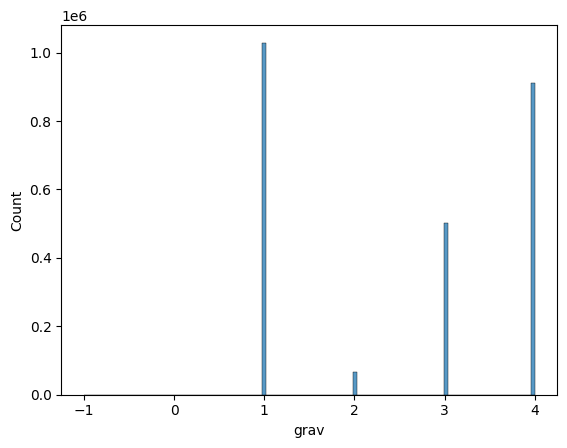

In [ ]:
dict1 = {
    -1:"NA",
    1:"Indemne",
    2:"Tué",
    3:"Blessé", # Blessé hospitalisé -> Blessé
    4:"Blessé", # Blessé léger -> Blessé
}

dict2 = {
    "NA":-1,
    "Indemne":0,
    "Blessé":1,
    "Tué":2,
    }

df_final_old["gravité"]=df_final_old["grav"].apply(lambda x:dict1[x])
df_final_old["grav_merged"]=df_final_old["gravité"].apply(lambda x:dict2[x])
sns.histplot(df_final_old["grav"])

In [ ]:
print((df_final_old["grav"]==-1).sum())
print(len(df_final_old))

60
2509620


In [ ]:
df_final_old=df_final_old[df_final_old["grav"]!=-1]

## Fusion des anciennes données et des nouvelles données

Steps suivants : 

Observons les différences dans les noms de colonnes du format des anciens datasets (2005-2021), et des nouveaux datasets (2022-2024).

In [ ]:
cols_recentes = set(df_final2224.columns)
cols_anciennes = set(df_final_old.columns)

unique_recent = cols_recentes-cols_anciennes # Soustraire les sets permet de ne garder que les colonnes uniquement présentes en 2022-2024
unique_ancien = cols_anciennes-cols_recentes # Colonnes uniquement présentes en 2005-2021

print(unique_ancien,unique_recent)

print(cols_anciennes,cols_recentes)

{'gps', 'grav_merged', 'secu', 'env1'} {'nb_param_lieux', 'grav_weight'}
{'gps', 'lum', 'grav_merged', 'col', 'larrout', 'int', 'actp', 'surf', 'secu', 'grav', 'jour', 'dep', 'lat', 'secu2', 'place', 'catr', 'hrmn', 'locp', 'nbv', 'an_nais', 'adr', 'year', 'lartpc', 'infra', 'Unnamed: 0', 'catu', 'circ', 'mois', 'atm', 'prof', 'etatp', 'Unnamed: 0_y', 'com', 'agg', 'id_vehicule', 'vma', 'trajet', 'plan', 'env1', 'vosp', 'num_veh', 'Unnamed: 0_x', 'situ', 'sexe', 'gravité', 'secu3', 'Num_Acc', 'secu1', 'long'} {'lum', 'col', 'larrout', 'int', 'actp', 'surf', 'dep', 'grav', 'jour', 'nb_param_lieux', 'lat', 'secu2', 'place', 'catr', 'hrmn', 'nbv', 'an_nais', 'secu1', 'adr', 'year', 'lartpc', 'infra', 'Unnamed: 0', 'catu', 'circ', 'mois', 'atm', 'prof', 'etatp', 'Unnamed: 0_y', 'com', 'agg', 'id_vehicule', 'vma', 'trajet', 'plan', 'vosp', 'grav_weight', 'num_veh', 'Unnamed: 0_x', 'situ', 'sexe', 'gravité', 'secu3', 'Num_Acc', 'locp', 'long'}


Comme on dispose déjà de donnée sur l'adresse de l'accident, et en particulier sur sa longitude et sa latitude, l'ancienne colonne GPS (qui ne prend qu'une seule mystérieuse valeur, "M") n'est pas utile. Nous pouvons la supprimer.
De même, la colonne id_usager n'est pas très intéressante. Elle peut apparaître plusieurs fois (si un individu fait plusieurs accidents dans l'année), mais nous pouvons déjà différencier les individus au sein d'un même numéro d'accident. Chaque accidenté de chaque accident est déjà indexé par l'index du dataframe.
Nous pouvons donc supprimer ces deux colonnes.

"env1" correspond à la proximité d'une école. Cette donnée n'est plus collectée et ne pourra pas être utilisée pour prédire la gravité d'un accident. Nous pouvons la supprimer.

Enfin, la colonne "secu" correspond de 2005 à 2021 à un code sur deux caractères : 

Le premier concerne l'existence d'un équipement de sécurité:
    
    1 – Ceinture,
    2 – Casque,
    3 – Dispositif enfants,
    4 – Equipement réfléchissant,
    9 – Autre

Le second concerne l'utilisation de cet équipement de sécurité :
    
    1 – Oui,
    2 – Non,
    3 – Non déterminable

Dans les versions plus récentes, il est question de l'existence ET de l'utilisation d'un équipement de sécurité, jusqu'à trois à la fois (secu1,secu2,secu3):
    
    -1 – Non renseigné  
    0 – Aucun équipement  
    1 – Ceinture  
    2 – Casque  
    3 – Dispositif enfants  
    4 – Gilet réfléchissant  
    5 – Airbag (2RM/3RM)  
    6 – Gants (2RM/3RM)  
    7 – Gants + Airbag (2RM/3RM)  
    8 – Non déterminable  
    9 – Autre

Cette nouvelle nomenclature (secu1,secu2,secu3) qui permet une analyse plus granulaire a été introduite en 2019, avec id_vehicule (identifiant du véhicule, que nous pouvons également abandonner).

Dans les étapes suivantes, nous pouvons donc abandonner "gps", "id_vehicule", "id_usager", et réfléchir à une modification de la colonne "secu" pour harmoniser les données 05-21 avec 22-24.


In [ ]:
df_final2224.drop(columns=["id_usager"],inplace=True,errors="ignore")
df_final_old.drop(columns=[["gps","env1"]],inplace=True,errors="ignore")
df_final_old["nb_param_lieux"]=1

In [ ]:
df_final2224

,Unnamed: 0_x,Num_Acc,year,id_vehicule,num_veh,place,catu,grav,sexe,an_nais,...,dep,com,agg,int,atm,col,adr,lat,long,grav_weight
0,0,202200000001,2022,813 952,A01,1.0,1,1.0,1.0,2008.0,...,26,26198,2,3,1,3,TEIL(vieille route du),"44,5594200000","4,7257200000",1.0
1,1,202200000001,2022,813 953,B01,1.0,1,0.0,1.0,1948.0,...,26,26198,2,3,1,3,TEIL(vieille route du),"44,5594200000","4,7257200000",0.0
2,2,202200000002,2022,813 950,B01,1.0,1,1.0,1.0,1988.0,...,25,25204,2,3,1,3,Miranda,"46,9258100000","6,3462000000",1.0
3,3,202200000002,2022,813 951,A01,1.0,1,0.0,1.0,1970.0,...,25,25204,2,3,1,3,Miranda,"46,9258100000","6,3462000000",0.0
4,4,202200000003,2022,813 948,A01,1.0,1,0.0,1.0,2002.0,...,22,22360,2,6,1,2,ROND POINT DE BREZILLET,"48,4931620000","-2,7604390000",0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377633,377633,202400054401,2024,155 686 119,Y01,1.0,1,1.0,2.0,1978.0,...,92,92012,2,1,1,3,JEAN JAURES (BOULEVARD) 63/215 - 70/208,"48,83286197","2,24394009",1.0
377634,377634,202400054401,2024,155 686 120,A01,1.0,1,0.0,1.0,1984.0,...,92,92012,2,1,1,3,JEAN JAURES (BOULEVARD) 63/215 - 70/208,"48,83286197","2,24394009",0.0
377635,377635,202400054402,2024,155 686 118,A01,1.0,1,1.0,1.0,1981.0,...,94,94028,2,1,1,4,Avenue de la Pompadour,"48,78330000","2,46660000",1.0
377636,377636,202400054402,2024,155 686 121,B01,1.0,1,1.0,2.0,1986.0,...,94,94028,2,1,1,4,Avenue de la Pompadour,"48,78330000","2,46660000",1.0


Maintenant, on fusionne certaines catégories de chaque feature, puis on applique un One-Hot Encoding.

In [ ]:
# Jour (1) -> 0
# Aube (2) + Nuit éclairée (5) -> 1
# Nuit sans éclairage (3) + Nuit éteinte (4) -> 2
mapping_lum_ordinal = {1: 0, 2: 1, 5: 1, 3: 2, 4: 2}

In [ ]:
map_atm = {
    # Conditions Normales (y compris éblouissant/couvert)
    1: 'Normale', 7: 'Normale', 8: 'Normale',
    # Conditions Humides
    2: 'Pluie', 3: 'Pluie',
    # Conditions Difficiles (Neige, Brouillard, Vent)
    4: 'Difficile', 5: 'Difficile', 6: 'Difficile',
    # Autres / Inconnu (Gère le -1 post-2019)
    9: 'Autre', -1: 'Autre'
}

In [ ]:
map_catr = {
    # Voies Rapides / Séparées
    1: 'Autoroute', 2: 'Nationale',
    # Voies Secondaires (souvent les plus mortelles)
    3: 'Departementale',
    # Ville / Urbain (Intègre Métropole code 7)
    4: 'Ville', 5: 'Ville', 6: 'Ville', 7: 'Ville', 9: 'Ville'
}

In [ ]:
map_int = {
    1: 'Hors_Intersection',
    # Intersections classiques (X, T, Y, >4)
    2: 'Intersection', 3: 'Intersection', 4: 'Intersection', 5: 'Intersection',
    # Intersections spéciales (Giratoire, Place, Passage à niveau)
    6: 'Giratoire_Place', 7: 'Giratoire_Place', 8: 'Autre', 9: 'Autre'
}

In [ ]:
map_col = {
    1: 'Frontale',
    2: 'Arriere',
    3: 'Cote',
    4: 'Chaine', 5: 'Chaine', # En chaîne ou multiples
    6: 'Autre', 7: 'Autre', -1: 'Autre'
}

Attaquons la feature "secu". 

In [ ]:
import numpy as np

# Dans le vieux dataset, le premier caractère de "secu" correspond à la présence de l'équipement de sécurité, et le deuxième dit s'il était équipé ou pas lors de l'accident.
df_final_old['secu'] = df_final_old['secu'].fillna(0).astype(int).astype(str).str.zfill(2)

# Création d'une variable "ceinture"
df_final_old['secu_ceinture'] = np.where(df_final_old['secu'] == '11', 1, 0)

# Création d'une variable "casque"
df_final_old['secu_casque'] = np.where(df_final_old['secu'] == '21', 1, 0)

# Vérification rapide
print("Répartition Ceinture (Avant 2019) :")
print(df_final_old['secu_ceinture'].value_counts())

print("\nRépartition Casque (Avant 2019) :")
print(df_final_old['secu_casque'].value_counts())

Répartition Ceinture (Avant 2019) :
secu_ceinture
0    1312093
1    1197467
Name: count, dtype: int64

Répartition Casque (Avant 2019) :
secu_casque
0    2120056
1     389504
Name: count, dtype: int64


<Axes: xlabel='secu', ylabel='count'>

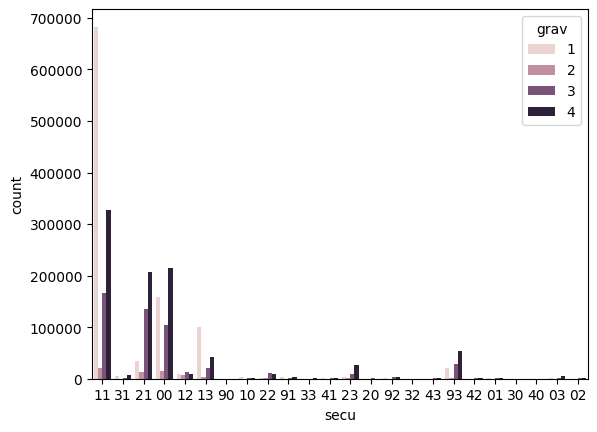

In [ ]:
sns.countplot(data=df_final_old,x="secu",hue="grav")

In [ ]:
df_final_old.drop(columns=["secu"],inplace=True,errors="ignore")

<Axes: xlabel='secu_ceinture', ylabel='count'>

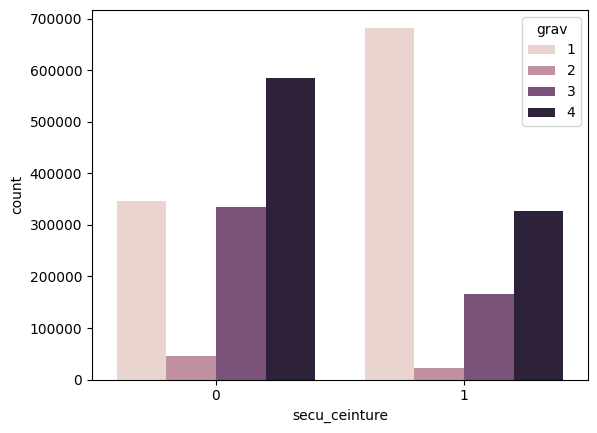

In [ ]:
sns.countplot(data=df_final_old,x="secu_ceinture",hue="grav")

In [ ]:
df_final_old[df_final_old["adr"].isna()]

,Unnamed: 0_x,Num_Acc,place,catu,grav,sexe,trajet,locp,actp,etatp,...,surf,infra,situ,env1,vma,gravité,grav_merged,nb_param_lieux,secu_ceinture,secu_casque
8,8,2.005000e+11,1.0,1,1,1,1.0,0.0,0,0.0,...,2.0,0.0,5.0,0.0,NaN,Indemne,0,1,0,1
9,9,2.005000e+11,1.0,1,3,1,1.0,0.0,0,0.0,...,2.0,0.0,5.0,0.0,NaN,Blessé,1,1,0,1
10,10,2.005000e+11,1.0,1,3,1,5.0,0.0,0,0.0,...,1.0,0.0,1.0,0.0,NaN,Blessé,1,1,1,0
11,11,2.005000e+11,2.0,2,3,2,0.0,0.0,0,0.0,...,1.0,0.0,1.0,0.0,NaN,Blessé,1,1,1,0
12,12,2.005000e+11,1.0,1,4,1,1.0,0.0,0,0.0,...,1.0,0.0,1.0,0.0,NaN,Blessé,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2508870,2508870,2.021001e+11,1.0,1,3,1,1.0,0.0,0,-1.0,...,NaN,NaN,NaN,NaN,NaN,Blessé,1,1,0,0
2508871,2508871,2.021001e+11,1.0,1,1,1,5.0,0.0,0,-1.0,...,NaN,NaN,NaN,NaN,NaN,Indemne,0,1,0,0
2509109,2509109,2.021001e+11,1.0,1,3,2,1.0,0.0,0,-1.0,...,NaN,NaN,NaN,NaN,NaN,Blessé,1,1,0,0
2509110,2509110,2.021001e+11,1.0,1,1,1,4.0,0.0,0,-1.0,...,NaN,NaN,NaN,NaN,NaN,Indemne,0,1,0,0
